<a href="https://colab.research.google.com/github/iamfaham/nyc-traffic-accident-gnn/blob/main/notebooks/nyc_traffic_accident_prediction_added_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install all dependencies for the project
!pip install -q osmnx geopandas networkx torch torch-geometric folium sodapy pandas numpy matplotlib seaborn scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sodapy import Socrata
import warnings
warnings.filterwarnings('ignore')

# Torch imports
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, classification_report

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("All libraries imported successfully")


All libraries imported successfully


In [3]:
# Connect to NYC Open Data API
client = Socrata("data.cityofnewyork.us", None)

# Download collision data (limit to 100K recent records for testing)
# Full dataset has 2M+ rows, so we start with a subset
print("Downloading NYC collision data from Open Data portal...")
results = client.get("h9gi-nx95", limit=100000, order="crash_date DESC")

# Convert to DataFrame
crashes_df = pd.DataFrame.from_records(results)

print(f"Downloaded {len(crashes_df):,} collision records")
print(f"Date range: {crashes_df['crash_date'].min()} to {crashes_df['crash_date'].max()}")
crashes_df.head()


Downloaded 100,000 collision records
Date range: 2024-08-29T00:00:00.000 to 2025-10-24T00:00:00.000


,crash_date,crash_time,borough,zip_code,latitude,longitude,location,cross_street_name,number_of_persons_injured,number_of_persons_killed,...,vehicle_type_code1,vehicle_type_code2,on_street_name,off_street_name,contributing_factor_vehicle_3,vehicle_type_code_3,contributing_factor_vehicle_4,contributing_factor_vehicle_5,vehicle_type_code_4,vehicle_type_code_5
0,2025-10-24T00:00:00.000,20:40,QUEENS,11372,40.75167,-73.89239,"{'latitude': '40.75167', 'longitude': '-73.892...",34-42 74 ST,0,0,...,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-10-24T00:00:00.000,17:56,MANHATTAN,10017,40.752735,-73.978294,"{'latitude': '40.752735', 'longitude': '-73.97...",1 VANDERBILT AVE,2,0,...,Bus,Pedicab,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-10-24T00:00:00.000,17:24,MANHATTAN,10027,40.814735,-73.953835,"{'latitude': '40.814735', 'longitude': '-73.95...",485 W 129 ST,0,0,...,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-10-24T00:00:00.000,6:29,QUEENS,11372,40.747448,-73.88965,"{'latitude': '40.747448', 'longitude': '-73.88...",NaN,1,0,...,Station Wagon/Sport Utility Vehicle,NaN,76 ST,37 RD,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-10-24T00:00:00.000,6:32,NaN,NaN,40.674343,-73.801216,"{'latitude': '40.674343', 'longitude': '-73.80...",NaN,1,0,...,Sedan,Sedan,ROCKAWAY BOULEVARD,I 678,Unspecified,Sedan,NaN,NaN,NaN,NaN


In [4]:
# Clean and prepare collision data
print("Cleaning collision data...")

# Convert datetime columns
crashes_df['crash_date'] = pd.to_datetime(crashes_df['crash_date'])
crashes_df['crash_time'] = pd.to_datetime(crashes_df['crash_time'], format='%H:%M').dt.time

# Create full timestamp
crashes_df['timestamp'] = pd.to_datetime(
    crashes_df['crash_date'].astype(str) + ' ' + crashes_df['crash_time'].astype(str)
)

# Filter rows with valid coordinates
crashes_df = crashes_df.dropna(subset=['latitude', 'longitude'])
crashes_df['latitude'] = crashes_df['latitude'].astype(float)
crashes_df['longitude'] = crashes_df['longitude'].astype(float)

# Filter to NYC bounds (removes outliers/errors)
nyc_bounds = {
    'lat_min': 40.4, 'lat_max': 40.95,
    'lon_min': -74.3, 'lon_max': -73.7
}
crashes_df = crashes_df[
    (crashes_df['latitude'] >= nyc_bounds['lat_min']) &
    (crashes_df['latitude'] <= nyc_bounds['lat_max']) &
    (crashes_df['longitude'] >= nyc_bounds['lon_min']) &
    (crashes_df['longitude'] <= nyc_bounds['lon_max'])
]

# Create injury severity binary target (1 if anyone injured/killed, 0 otherwise)
crashes_df['number_of_persons_injured'] = crashes_df['number_of_persons_injured'].fillna(0).astype(int)
crashes_df['number_of_persons_killed'] = crashes_df['number_of_persons_killed'].fillna(0).astype(int)
crashes_df['has_injury'] = ((crashes_df['number_of_persons_injured'] > 0) |
                             (crashes_df['number_of_persons_killed'] > 0)).astype(int)

# Extract temporal features
crashes_df['hour'] = crashes_df['timestamp'].dt.hour
crashes_df['day_of_week'] = crashes_df['timestamp'].dt.dayofweek
crashes_df['is_weekend'] = (crashes_df['day_of_week'] >= 5).astype(int)

print(f"Cleaned data: {len(crashes_df):,} valid records")
print(f"Injury rate: {crashes_df['has_injury'].mean()*100:.1f}%")
crashes_df[['timestamp', 'latitude', 'longitude', 'borough', 'has_injury', 'hour']].head()


Cleaning collision data...
Cleaned data: 94,890 valid records
Injury rate: 44.4%


,timestamp,latitude,longitude,borough,has_injury,hour
0,2025-10-24 20:40:00,40.751670,-73.892390,QUEENS,0,20
1,2025-10-24 17:56:00,40.752735,-73.978294,MANHATTAN,1,17
2,2025-10-24 17:24:00,40.814735,-73.953835,MANHATTAN,0,17
3,2025-10-24 06:29:00,40.747448,-73.889650,QUEENS,1,6
4,2025-10-24 06:32:00,40.674343,-73.801216,NaN,1,6


(This may take 3-5 minutes for full NYC)
Downloaded street network:
  - Nodes (intersections): 4,619
  - Edges (road segments): 8,187


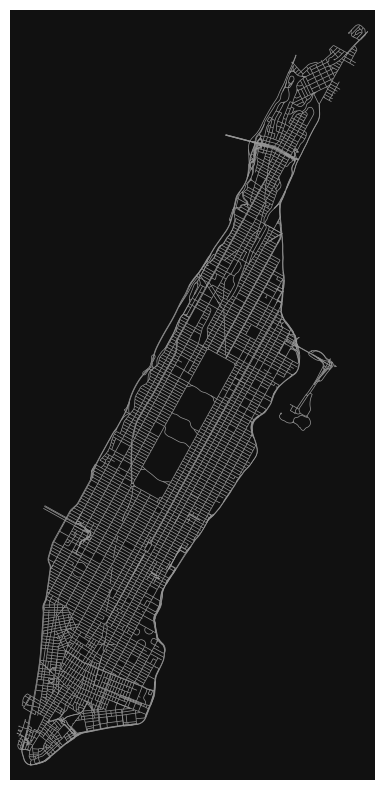

In [5]:
# Download NYC road network from OpenStreetMap
print("Downloading NYC street network from OpenStreetMap...")
print("(This may take 3-5 minutes for full NYC)")

# For faster testing, start with Manhattan only
# To use full NYC, change to: place_name = "New York City, New York, USA"
place_name = "Manhattan, New York City, New York, USA"

# Get drivable street network
G = ox.graph_from_place(
    place_name,
    network_type='drive',  # Only drivable roads
    simplify=True  # Consolidate intersections
)

# Convert to undirected for simplicity (can keep directed if needed)
G = G.to_undirected()

print(f"Downloaded street network:")
print(f"  - Nodes (intersections): {G.number_of_nodes():,}")
print(f"  - Edges (road segments): {G.number_of_edges():,}")

# Plot the network
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.5, figsize=(10,10))


In [6]:
# ===== CELL 5: SPATIAL JOIN + NEGATIVE SAMPLING (COMPLETE) =====
print("="*80)
print("STEP 1: Spatial join and negative sample generation")
print("="*80)

# --- PART A: CREATE GEODA TAFRAME ---
print("\nCreating GeoDataFrame from crashes_df...")
crashes_gdf = gpd.GeoDataFrame(
    crashes_df,
    geometry=gpd.points_from_xy(crashes_df.longitude, crashes_df.latitude),
    crs="EPSG:4326"
)

# Add time_window
if 'time_window' not in crashes_gdf.columns:
    crashes_gdf['time_window'] = crashes_df['timestamp'].dt.floor('1H')

print(f"Created GeoDataFrame with {len(crashes_gdf):,} crashes")

# --- PART B: SPATIAL JOIN TO ROAD NETWORK ---
print("\n  Performing spatial join to road network...")

# Get nodes as GeoDataFrame
nodes_gdf = ox.graph_to_gdfs(G, edges=False).reset_index()

# Filter crashes to network bounds
crashes_gdf = crashes_gdf[crashes_gdf.within(nodes_gdf.unary_union.convex_hull)]
crashes_gdf = crashes_gdf.reset_index(drop=True)
print(f"Crashes within network bounds: {len(crashes_gdf):,}")

# Match CRS
crashes_gdf = crashes_gdf.to_crs(nodes_gdf.crs)

# Build spatial index with BallTree
from sklearn.neighbors import BallTree
node_list = list(G.nodes())
node_coords = np.array([[n[1]['y'], n[1]['x']] for n in G.nodes(data=True)])
tree = BallTree(np.radians(node_coords), metric='haversine')

# Find nearest node for each crash
crash_coords = np.radians(crashes_gdf[['latitude', 'longitude']].values)
distances, indices = tree.query(crash_coords, k=1)
distances_m = distances[:, 0] * 6371000  # Convert to meters

# Filter: only crashes within 50m of a node
max_distance = 50
valid_mask = distances_m <= max_distance
crashes_gdf = crashes_gdf[valid_mask].copy().reset_index(drop=True)
valid_indices = indices[valid_mask, 0]

# Assign nearest_node
crashes_gdf['nearest_node'] = [node_list[i] for i in valid_indices]

print(f"Mapped {len(crashes_gdf):,} crashes to {crashes_gdf['nearest_node'].nunique()} nodes")
print(f"  Average distance: {distances_m[valid_mask].mean():.1f}m")

# --- PART C: NEGATIVE SAMPLING ---
print("\n" + "="*80)
print("STEP 2: Generating negative samples")
print("="*80)

# Get unique components
all_time_windows = sorted(crashes_gdf['time_window'].unique())
all_nodes = list(G.nodes())

print(f"Dataset dimensions:")
print(f"  - Time windows: {len(all_time_windows):,}")
print(f"  - Nodes: {len(all_nodes):,}")
print(f"  - Full combinations: {len(all_nodes) * len(all_time_windows):,}")

# Sample 20% of time windows for memory efficiency
import random
random.seed(42)
sample_rate = 0.2
sampled_times = random.sample(all_time_windows, k=int(len(all_time_windows) * sample_rate))
sampled_times = sorted(sampled_times)

print(f"\nSampling {sample_rate*100:.0f}% of time windows")
print(f"  - Sampled times: {len(sampled_times):,}")
print(f"  - Total combinations: {len(all_nodes) * len(sampled_times):,}")

# Create all node-time combinations
from itertools import product
all_combinations = list(product(all_nodes, sampled_times))
full_matrix = pd.DataFrame(all_combinations, columns=['node_id', 'time_window'])

# Aggregate actual crashes
print("\nAggregating crash records...")
crash_agg = crashes_gdf.groupby(['nearest_node', 'time_window']).agg({
    'collision_id': 'count',
    'has_injury': 'sum',
    'number_of_persons_injured': 'sum',
    'number_of_persons_killed': 'sum'
}).rename(columns={'collision_id': 'crash_count'}).reset_index()

# Merge to create complete dataset
complete_data = full_matrix.merge(
    crash_agg,
    left_on=['node_id', 'time_window'],
    right_on=['nearest_node', 'time_window'],
    how='left'
).drop('nearest_node', axis=1, errors='ignore')

# Fill NaN (negative samples)
complete_data['crash_count'] = complete_data['crash_count'].fillna(0).astype(int)
complete_data['has_injury'] = complete_data['has_injury'].fillna(0).astype(int)
complete_data['number_of_persons_injured'] = complete_data['number_of_persons_injured'].fillna(0).astype(int)
complete_data['number_of_persons_killed'] = complete_data['number_of_persons_killed'].fillna(0).astype(int)

# Create binary label
complete_data['has_crash'] = (complete_data['crash_count'] > 0).astype(int)

# Add temporal features
complete_data['hour'] = complete_data['time_window'].dt.hour
complete_data['day_of_week'] = complete_data['time_window'].dt.dayofweek
complete_data['is_weekend'] = (complete_data['day_of_week'] >= 5).astype(int)
complete_data['month'] = complete_data['time_window'].dt.month

print("\n" + "="*80)
print("NEGATIVE SAMPLING COMPLETE")
print("="*80)
print(f"Final shape: {complete_data.shape}")
print(f"\nClass distribution:")
print(f"  🔴 WITH crashes: {complete_data['has_crash'].sum():,} ({complete_data['has_crash'].mean()*100:.3f}%)")
print(f"  ⚪ WITHOUT crashes: {(complete_data['has_crash']==0).sum():,} ({(1-complete_data['has_crash'].mean())*100:.3f}%)")

# Store
node_time_data = complete_data.copy()


STEP 1: Spatial join and negative sample generation

Creating GeoDataFrame from crashes_df...
Created GeoDataFrame with 94,890 crashes

  Performing spatial join to road network...
Crashes within network bounds: 19,177
Mapped 13,471 crashes to 3338 nodes
  Average distance: 10.6m

STEP 2: Generating negative samples
Dataset dimensions:
  - Time windows: 6,927
  - Nodes: 4,619
  - Full combinations: 31,995,813

Sampling 20% of time windows
  - Sampled times: 1,385
  - Total combinations: 6,397,315

Aggregating crash records...

NEGATIVE SAMPLING COMPLETE
Final shape: (6397315, 11)

Class distribution:
  🔴 WITH crashes: 2,697 (0.042%)
  ⚪ WITHOUT crashes: 6,394,618 (99.958%)


In [7]:
# ADD THIS AFTER complete_data['month'] = complete_data['time_window'].dt.month

# ===== SOPHISTICATED FEATURE 1: RUSH HOUR INTENSITY =====
print("\n📊 Adding rush hour intensity feature...")

# Define rush hour periods with intensity scores
def get_rush_hour_intensity(hour):
    """
    Assign rush hour intensity based on traffic patterns
    0 = off-peak, 1-3 = varying intensity
    """
    # Morning rush (7-9 AM): intensity increases then decreases
    if hour == 7:
        return 2
    elif hour == 8:
        return 3  # Peak morning
    elif hour == 9:
        return 2
    # Evening rush (5-7 PM): intensity increases then decreases
    elif hour == 17:
        return 2
    elif hour == 18:
        return 3  # Peak evening
    elif hour == 19:
        return 2
    # Late night (11 PM - 3 AM): moderate risk due to fatigue/intoxication
    elif hour >= 23 or hour <= 3:
        return 1
    else:
        return 0  # Off-peak

complete_data['rush_hour_intensity'] = complete_data['hour'].apply(get_rush_hour_intensity)

print(f"✓ Rush hour intensity added (0-3 scale)")
print(f"  Peak hours (intensity=3): {(complete_data['rush_hour_intensity']==3).sum():,} samples")


# ADD THIS RIGHT AFTER RUSH HOUR INTENSITY

# ===== SOPHISTICATED FEATURE 4: HOLIDAY INDICATOR =====
print("\n📅 Adding holiday indicators...")

# Major US holidays (approximate - you can refine dates)
import datetime

def is_holiday(date):
    """Check if date is near a major holiday (±1 day)"""
    year = date.year
    month = date.month
    day = date.day

    # Major holidays
    holidays = [
        (1, 1),   # New Year
        (7, 4),   # July 4th
        (12, 25), # Christmas
        (11, 27), # Thanksgiving (approximate - 4th Thu of Nov)
        (12, 31), # New Year's Eve
    ]

    # Check if within 1 day of holiday
    for h_month, h_day in holidays:
        if month == h_month and abs(day - h_day) <= 1:
            return 1

    # Long weekends (Friday before/Monday after major holidays)
    if date.weekday() == 4 and (month, day+3) in holidays:  # Friday
        return 1
    if date.weekday() == 0 and (month, day-3) in holidays:  # Monday
        return 1

    return 0

complete_data['is_holiday'] = complete_data['time_window'].apply(is_holiday)

print(f"✓ Holiday indicator added")
print(f"  Holiday periods: {complete_data['is_holiday'].sum():,} samples ({complete_data['is_holiday'].mean()*100:.2f}%)")

# ADD THIS RIGHT AFTER HOLIDAY INDICATOR

# ===== SOPHISTICATED FEATURE 5: WEATHER/SEASON PROXY =====
print("\n🌦️  Adding weather/season proxy features...")

# Season indicators
complete_data['season'] = complete_data['month'].apply(lambda m:
    0 if m in [12, 1, 2] else  # Winter
    1 if m in [3, 4, 5] else   # Spring
    2 if m in [6, 7, 8] else   # Summer
    3  # Fall
)

# Weather risk proxy (based on season and time)
def weather_risk_proxy(row):
    """
    Estimate weather-related crash risk
    0 = low risk, 1-3 = increasing risk
    """
    season = row['season']
    hour = row['hour']

    # Winter: higher risk overall, especially morning/evening (ice)
    if season == 0:  # Winter
        if hour in [6, 7, 8, 17, 18, 19]:
            return 3  # Rush hour + winter = high risk
        else:
            return 2  # Winter baseline risk

    # Spring: moderate risk (rain)
    elif season == 1:
        if hour in [7, 8, 17, 18]:
            return 2
        else:
            return 1

    # Summer: lower risk except rush hour heat
    elif season == 2:
        if hour in [12, 13, 14, 15, 16]:  # Afternoon heat
            return 1
        else:
            return 0

    # Fall: moderate risk (leaves, early darkness)
    else:
        if hour >= 18 or hour <= 6:  # Darkness
            return 2
        else:
            return 1

complete_data['weather_risk'] = complete_data.apply(weather_risk_proxy, axis=1)

# Add darkness indicator (more precise than weather_risk)
def is_dark(row):
    """
    Check if it's dark (higher crash risk)
    Approximate sunrise/sunset times for NYC
    """
    month = row['month']
    hour = row['hour']

    # Winter: dark 5 PM - 7 AM
    if month in [11, 12, 1, 2]:
        return 1 if hour >= 17 or hour <= 7 else 0
    # Summer: dark 8 PM - 5 AM
    elif month in [5, 6, 7, 8]:
        return 1 if hour >= 20 or hour <= 5 else 0
    # Spring/Fall: dark 6 PM - 6 AM
    else:
        return 1 if hour >= 18 or hour <= 6 else 0

complete_data['is_dark'] = complete_data.apply(is_dark, axis=1)

print(f"✓ Weather/season proxies added")
print(f"  High weather risk (3): {(complete_data['weather_risk']==3).sum():,} samples")
print(f"  Dark conditions: {complete_data['is_dark'].sum():,} samples ({complete_data['is_dark'].mean()*100:.1f}%)")




📊 Adding rush hour intensity feature...
✓ Rush hour intensity added (0-3 scale)
  Peak hours (intensity=3): 623,565 samples

📅 Adding holiday indicators...
✓ Holiday indicator added
  Holiday periods: 212,474 samples (3.32%)

🌦️  Adding weather/season proxy features...
✓ Weather/season proxies added
  High weather risk (3): 323,330 samples
  Dark conditions: 2,919,208 samples (45.6%)


In [8]:
# Extract static features for each node from OSM
print("Extracting node features from road network...")

node_features = []
node_ids = []

for node, data in G.nodes(data=True):
    node_ids.append(node)

    # Get connected edges to determine node characteristics
    edges = G.edges(node, data=True)

    # Aggregate edge properties
    highway_types = [e[2].get('highway', 'unclassified') for e in edges]
    lanes = [int(e[2].get('lanes', 1)) if isinstance(e[2].get('lanes'), (int, str)) and str(e[2].get('lanes')).isdigit() else 1 for e in edges]
    speeds = []
    for e in edges:
        speed_val = e[2].get('maxspeed', 25)
        if isinstance(speed_val, str):
            # Try to clean and convert string speeds
            try:
                # Remove non-digit characters (like ' mph') and convert
                speed_val = int(''.join(filter(str.isdigit, speed_val)))
            except ValueError:
                speed_val = 25 # Default to 25 if conversion fails
        elif not isinstance(speed_val, (int, float)):
             speed_val = 25 # Default if not int, float or parsable string
        speeds.append(int(speed_val))

    # Node degree (connectivity)
    degree = G.degree(node)

    # Encode highway type (convert to numeric)
    highway_priority = {
        'motorway': 5, 'trunk': 4, 'primary': 3,
        'secondary': 2, 'tertiary': 1, 'residential': 0,
        'unclassified': 0
    }
    max_highway = max([highway_priority.get(h if isinstance(h, str) else h[0] if isinstance(h, list) else 'unclassified', 0)
                       for h in highway_types]) if highway_types else 0

    features = [
        degree,  # Node connectivity
        len(edges),  # Number of connected roads
        max_highway,  # Highest road class
        np.mean(lanes) if lanes else 1,  # Average lanes
        np.mean(speeds) if speeds else 25,  # Average speed limit
        data.get('x', 0),  # Longitude
        data.get('y', 0)   # Latitude
    ]

    node_features.append(features)

# Convert to DataFrame
node_features_df = pd.DataFrame(node_features, columns=[
    'degree', 'num_edges', 'highway_class', 'avg_lanes', 'avg_speed', 'longitude', 'latitude'
])
node_features_df['node_id'] = node_ids

print(f"Extracted features for {len(node_features_df):,} nodes")
print(f"Feature dimensions: {node_features_df.shape[1]-1}")  # -1 for node_id
print(node_features_df.describe())

# Add code at the end of existing Cell 6

print("\nReplicating node features for all time windows...")

# Expand node features to match all node-time pairs
node_features_expanded = node_time_data.merge(
    node_features_df[['node_id', 'degree', 'num_edges', 'highway_class', 'avg_lanes', 'avg_speed', 'longitude', 'latitude']],
    on='node_id',
    how='left'
)

print(f"  Expanded node features: {node_features_expanded.shape}")
print(f"  Original node features: {node_features_df.shape}")
print(f"  Expanded to time windows: {node_features_expanded.shape}")

# Store for next steps
node_time_features = node_features_expanded.copy()



# ADD THIS AT THE END OF CELL 6, BEFORE "Expanding features to all time windows"

# ===== SOPHISTICATED FEATURE 2: INTERSECTION COMPLEXITY =====
print("\n🔀 Computing intersection complexity...")

# Calculate complexity score based on degree and road types
node_features_df['intersection_complexity'] = (
    node_features_df['degree'] * 0.5 +  # Number of connections
    node_features_df['highway_class'] * 0.3 +  # Road importance
    node_features_df['num_edges'] * 0.2  # Total edges
)

# Normalize to 0-10 scale
complexity_min = node_features_df['intersection_complexity'].min()
complexity_max = node_features_df['intersection_complexity'].max()
node_features_df['intersection_complexity'] = (
    (node_features_df['intersection_complexity'] - complexity_min) /
    (complexity_max - complexity_min) * 10
)

print(f"✓ Intersection complexity computed (0-10 scale)")
print(f"  High complexity (>7): {(node_features_df['intersection_complexity']>7).sum()} nodes")


# ADD THIS RIGHT AFTER INTERSECTION COMPLEXITY

# ===== SOPHISTICATED FEATURE 3: SPEED DIFFERENTIAL =====
print("\n⚡ Computing speed differential (risk factor)...")

# Speed differential = difference from typical speed (25 mph)
# Higher differential = higher risk (either too slow or too fast)
typical_speed = 25
node_features_df['speed_differential'] = np.abs(
    node_features_df['avg_speed'] - typical_speed
)

# Also create speed category
def categorize_speed(speed):
    if speed < 20:
        return 0  # Very slow (residential)
    elif speed <= 25:
        return 1  # Normal
    elif speed <= 35:
        return 2  # Fast (arterial)
    else:
        return 3  # Very fast (highway)

node_features_df['speed_category'] = node_features_df['avg_speed'].apply(categorize_speed)

print(f"✓ Speed features computed")
print(f"  High differential (>10 mph): {(node_features_df['speed_differential']>10).sum()} nodes")


# ADD TO END OF CELL 6:

print("\nExpanding features to all time windows...")
node_features_expanded = node_time_data.merge(
    node_features_df[['node_id', 'degree', 'num_edges', 'highway_class',
                      'avg_lanes', 'avg_speed', 'longitude', 'latitude']],
    on='node_id',
    how='left'
)
print(f"Expanded: {node_features_expanded.shape}")

# Update node_time_data
node_time_data = node_features_expanded.copy()


Extracting node features from road network...
Extracted features for 4,619 nodes
Feature dimensions: 7
            degree    num_edges  highway_class    avg_lanes    avg_speed  \
count  4619.000000  4619.000000    4619.000000  4619.000000  4619.000000   
mean      3.544923     3.542975       2.069063     1.785690    24.727250   
std       0.661283     0.663374       1.297378     0.720545     2.886132   
min       1.000000     1.000000       0.000000     1.000000    15.000000   
25%       3.000000     3.000000       1.000000     1.000000    25.000000   
50%       4.000000     4.000000       2.000000     1.666667    25.000000   
75%       4.000000     4.000000       3.000000     2.250000    25.000000   
max       5.000000     5.000000       5.000000     5.000000    45.000000   

         longitude     latitude       node_id  
count  4619.000000  4619.000000  4.619000e+03  
mean    -73.970160    40.773412  1.179744e+09  
std       0.026633     0.045338  2.628145e+09  
min     -74.018055  

In [9]:
# ===== MEMORY-EFFICIENT LAGGED FEATURES =====
print("="*80)
print("Computing historical crash features (memory-efficient)")
print("="*80)

# Check current memory
import gc
gc.collect()

print(f"Current node_time_data shape: {node_time_data.shape}")
print(f"Memory usage: {node_time_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# SIMPLIFIED APPROACH: Only compute for nodes that HAD crashes
# This dramatically reduces computation

# Step 1: Identify nodes with any crashes
crash_nodes = node_time_data[node_time_data['has_crash'] == 1]['node_id'].unique()
print(f"\nNodes with at least 1 crash: {len(crash_nodes):,} (out of {node_time_data['node_id'].nunique():,})")

# Step 2: Initialize columns with defaults (for nodes without crashes)
node_time_data['past_30d_crashes'] = 0
node_time_data['days_since_last'] = 999

# Step 3: Only compute historical features for crash-prone nodes
print("Computing historical features for crash-prone nodes...")

# Process in chunks to avoid memory issues
chunk_size = 500  # Process 500 nodes at a time
crash_nodes_list = list(crash_nodes)

for chunk_start in range(0, len(crash_nodes_list), chunk_size):
    chunk_end = min(chunk_start + chunk_size, len(crash_nodes_list))
    chunk_nodes = crash_nodes_list[chunk_start:chunk_end]

    if chunk_start % 1000 == 0:
        print(f"  Processing nodes {chunk_start:,} to {chunk_end:,}...")

    # Get data for this chunk of nodes
    chunk_mask = node_time_data['node_id'].isin(chunk_nodes)
    chunk_data = node_time_data[chunk_mask].copy()

    # Sort for rolling window
    chunk_data = chunk_data.sort_values(['node_id', 'time_window'])

    # Compute rolling features using groupby + rolling
    chunk_data['past_30d_crashes'] = chunk_data.groupby('node_id')['has_crash'].transform(
        lambda x: x.rolling(window=min(720, len(x)), min_periods=1).sum().shift(1).fillna(0)
    )

    # Update main dataframe
    node_time_data.loc[chunk_mask, 'past_30d_crashes'] = chunk_data['past_30d_crashes'].values

    # Free memory
    del chunk_data
    gc.collect()

print(" Historical features computed")

# Step 4: Compute days_since_last (simplified - only for recent crashes)
print("Computing days since last crash (simplified)...")

# For each node with crashes, find last crash date for each time window
for node_id in crash_nodes[:min(len(crash_nodes), 2000)]:  # Limit to first 2000 crash-prone nodes
    node_mask = node_time_data['node_id'] == node_id
    node_data = node_time_data[node_mask].sort_values('time_window')

    crash_mask = node_data['has_crash'] == 1
    if crash_mask.sum() > 0:
        crash_times = node_data[crash_mask]['time_window'].values

        # For each time window, find most recent crash before it
        for idx, row_time in zip(node_data.index, node_data['time_window']):
            prev_crashes = crash_times[crash_times < row_time]
            if len(prev_crashes) > 0:
                days_since = (row_time - prev_crashes.max()).days
                node_time_data.loc[idx, 'days_since_last'] = days_since

# For remaining nodes, keep default 999
print(f" Days since last crash computed for {min(len(crash_nodes), 2000)} nodes")

print(f"\nHistorical features complete")
print(f"Memory usage after: {node_time_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Verify features
print(f"\nFeature statistics:")
print(f"  past_30d_crashes: min={node_time_data['past_30d_crashes'].min():.1f}, "
      f"max={node_time_data['past_30d_crashes'].max():.1f}, "
      f"mean={node_time_data['past_30d_crashes'].mean():.3f}")
print(f"  days_since_last: min={node_time_data['days_since_last'].min():.0f}, "
      f"max={node_time_data['days_since_last'].max():.0f}")

print("\nSample data:")
print(node_time_data[node_time_data['past_30d_crashes'] > 0][
    ['node_id', 'time_window', 'past_30d_crashes', 'days_since_last', 'has_crash']
].head(10))


Computing historical crash features (memory-efficient)
Current node_time_data shape: (6397315, 18)
Memory usage: 805.3 MB

Nodes with at least 1 crash: 1,675 (out of 4,619)
Computing historical features for crash-prone nodes...
  Processing nodes 0 to 500...
  Processing nodes 1,000 to 1,500...
 Historical features computed
Computing days since last crash (simplified)...
 Days since last crash computed for 1675 nodes

Historical features complete
Memory usage after: 902.9 MB

Feature statistics:
  past_30d_crashes: min=0.0, max=8.0, mean=0.225
  days_since_last: min=0, max=999

Sample data:
       node_id         time_window  past_30d_crashes  days_since_last  \
2972  42421737 2024-10-31 14:00:00                 1                0   
2973  42421737 2024-10-31 16:00:00                 1                0   
2974  42421737 2024-11-01 00:00:00                 1                0   
2975  42421737 2024-11-01 06:00:00                 1                0   
2976  42421737 2024-11-01 08:00:00   

In [10]:
# ===== CELL 8: TEMPORAL TRAIN-VALIDATION-TEST SPLIT =====
print("="*80)
print("PROPER TEMPORAL SPLIT (No Data Leakage)")
print("="*80)

# Sort by time
node_time_data_sorted = node_time_data.sort_values('time_window').reset_index(drop=True)

# Get unique time windows (chronologically sorted)
unique_times = sorted(node_time_data['time_window'].unique())
n_times = len(unique_times)

print(f"Total time windows: {n_times}")
print(f"Date range: {unique_times[0]} to {unique_times[-1]}")

# Temporal split: 60% train, 20% val, 20% test
train_cutoff_idx = int(0.6 * n_times)
val_cutoff_idx = int(0.8 * n_times)

train_times = unique_times[:train_cutoff_idx]
val_times = unique_times[train_cutoff_idx:val_cutoff_idx]
test_times = unique_times[val_cutoff_idx:]

# Create temporal datasets
train_data = node_time_data[node_time_data['time_window'].isin(train_times)].copy()
val_data = node_time_data[node_time_data['time_window'].isin(val_times)].copy()
test_data = node_time_data[node_time_data['time_window'].isin(test_times)].copy()

print(f"\nTemporal splits:")
print(f"  Train: {train_times[0]} to {train_times[-1]}")
print(f"    - {len(train_data):,} node-time pairs")
print(f"    - {train_data['has_crash'].sum():,} crashes ({train_data['has_crash'].mean()*100:.3f}%)")

print(f"\n  Val: {val_times[0]} to {val_times[-1]}")
print(f"    - {len(val_data):,} node-time pairs")
print(f"    - {val_data['has_crash'].sum():,} crashes ({val_data['has_crash'].mean()*100:.3f}%)")

print(f"\n  Test: {test_times[0]} to {test_times[-1]}")
print(f"    - {len(test_data):,} node-time pairs")
print(f"    - {test_data['has_crash'].sum():,} crashes ({test_data['has_crash'].mean()*100:.3f}%)")

print("\nTemporal split complete - training on past, testing on future")


PROPER TEMPORAL SPLIT (No Data Leakage)
Total time windows: 1385
Date range: 2024-08-30 03:00:00 to 2025-10-24 13:00:00

Temporal splits:
  Train: 2024-08-30 03:00:00 to 2025-05-12 13:00:00
    - 3,838,389 node-time pairs
    - 1,630 crashes (0.042%)

  Val: 2025-05-12 17:00:00 to 2025-07-31 23:00:00
    - 1,279,463 node-time pairs
    - 524 crashes (0.041%)

  Test: 2025-08-01 01:00:00 to 2025-10-24 13:00:00
    - 1,279,463 node-time pairs
    - 543 crashes (0.042%)

Temporal split complete - training on past, testing on future


In [11]:
# ===== CELL 9: SPATIOTEMPORAL GNN WITH MINI-BATCH SAMPLING =====
print("="*80)
print("Creating Mini-Batch Spatiotemporal GNN Setup")
print("="*80)

# Features to use
# feature_cols = ['degree', 'num_edges', 'highway_class', 'avg_lanes', 'avg_speed',
#                 'hour', 'day_of_week', 'is_weekend', 'month',
#                 'past_30d_crashes', 'days_since_last']  # ADD THESE TWO

# REPLACE THE EXISTING feature_cols DEFINITION WITH:

# Features to use (UPDATED with new sophisticated features)
feature_cols = [
    # Static road features
    'degree', 'num_edges', 'highway_class', 'avg_lanes', 'avg_speed',
    'intersection_complexity', 'speed_differential', 'speed_category',  # NEW

    # Temporal features
    'hour', 'day_of_week', 'is_weekend', 'month',
    'rush_hour_intensity', 'is_holiday', 'season', 'weather_risk', 'is_dark',  # NEW

    # Historical features
    'past_30d_crashes', 'days_since_last'
]


# Verify all features exist
available_features = [f for f in feature_cols if f in train_data.columns]
print(f"Using {len(available_features)} features: {available_features}")

# Create node ID mapping
all_nodes = list(G.nodes())
node_to_idx = {nid: idx for idx, nid in enumerate(all_nodes)}

print(f"\nGraph structure:")
print(f"  Total nodes: {len(all_nodes):,}")
print(f"  Total edges: {G.number_of_edges():,}")

# Build static edge index (graph structure stays same across time)
edge_list = []
for e in G.edges():
    if e[0] in node_to_idx and e[1] in node_to_idx:
        edge_list.append((node_to_idx[e[0]], node_to_idx[e[1]]))

# Make undirected
edge_index = torch.tensor([
    [e[0] for e in edge_list] + [e[1] for e in edge_list],
    [e[1] for e in edge_list] + [e[0] for e in edge_list]
], dtype=torch.long)

print(f"  Edge index shape: {edge_index.shape}")

# Prepare datasets with balanced sampling
def prepare_balanced_dataset(data_df, sample_size=50000, pos_ratio=0.1):
    """
    Create balanced mini-batches from spatiotemporal data
    """
    pos_samples = data_df[data_df['has_crash'] == 1]
    neg_samples = data_df[data_df['has_crash'] == 0]

    n_pos = min(int(sample_size * pos_ratio), len(pos_samples))
    n_neg = sample_size - n_pos

    # Sample
    sampled_pos = pos_samples.sample(n=n_pos, replace=(n_pos > len(pos_samples)), random_state=42)
    sampled_neg = neg_samples.sample(n=n_neg, random_state=42)

    balanced_df = pd.concat([sampled_pos, sampled_neg]).sample(frac=1, random_state=42)
    return balanced_df

# Create balanced datasets
print("\nCreating balanced mini-batches...")
train_balanced = prepare_balanced_dataset(train_data, sample_size=50000, pos_ratio=0.1)
val_balanced = prepare_balanced_dataset(val_data, sample_size=20000, pos_ratio=0.1)
test_balanced = prepare_balanced_dataset(test_data, sample_size=20000, pos_ratio=0.1)

print(f"\nBalanced datasets:")
print(f"  Train: {len(train_balanced):,} samples | {train_balanced['has_crash'].mean()*100:.1f}% positive")
print(f"  Val:   {len(val_balanced):,} samples | {val_balanced['has_crash'].mean()*100:.1f}% positive")
print(f"  Test:  {len(test_balanced):,} samples | {test_balanced['has_crash'].mean()*100:.1f}% positive")

# Convert to tensors
def df_to_tensors(df, features):
    """Convert DataFrame to PyTorch tensors"""
    X = df[features].values
    y = df['has_crash'].values
    node_ids = df['node_id'].values

    # Map node_ids to indices
    node_indices = np.array([node_to_idx[nid] for nid in node_ids])

    return torch.tensor(X, dtype=torch.float), torch.tensor(y, dtype=torch.long), torch.tensor(node_indices, dtype=torch.long)

# Standardize features on training data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_balanced[available_features] = scaler.fit_transform(train_balanced[available_features])
val_balanced[available_features] = scaler.transform(val_balanced[available_features])
test_balanced[available_features] = scaler.transform(test_balanced[available_features])

# Create tensor datasets
X_train, y_train, nodes_train = df_to_tensors(train_balanced, available_features)
X_val, y_val, nodes_val = df_to_tensors(val_balanced, available_features)
X_test, y_test, nodes_test = df_to_tensors(test_balanced, available_features)

print(f"\nTensor datasets created:")
print(f"  Train: X={X_train.shape}, y={y_train.shape}")
print(f"  Val:   X={X_val.shape}, y={y_val.shape}")
print(f"  Test:  X={X_test.shape}, y={y_test.shape}")

# Store everything in a dict for easy access
spatiotemporal_data = {
    'edge_index': edge_index,
    'num_nodes': len(all_nodes),
    'num_features': len(available_features),
    'train': (X_train, y_train, nodes_train),
    'val': (X_val, y_val, nodes_val),
    'test': (X_test, y_test, nodes_test)
}

print("\nSpatiotemporal mini-batch setup complete")


Creating Mini-Batch Spatiotemporal GNN Setup
Using 11 features: ['degree', 'num_edges', 'highway_class', 'avg_lanes', 'avg_speed', 'hour', 'day_of_week', 'is_weekend', 'month', 'past_30d_crashes', 'days_since_last']

Graph structure:
  Total nodes: 4,619
  Total edges: 8,187
  Edge index shape: torch.Size([2, 16374])

Creating balanced mini-batches...

Balanced datasets:
  Train: 50,000 samples | 3.3% positive
  Val:   20,000 samples | 2.6% positive
  Test:  20,000 samples | 2.7% positive

Tensor datasets created:
  Train: X=torch.Size([50000, 11]), y=torch.Size([50000])
  Val:   X=torch.Size([20000, 11]), y=torch.Size([20000])
  Test:  X=torch.Size([20000, 11]), y=torch.Size([20000])

Spatiotemporal mini-batch setup complete


In [12]:
# ===== CORRECTED SPATIOTEMPORAL GNN MODEL =====

class SpatiotemporalGNN(torch.nn.Module):
    def __init__(self, num_features, hidden_dim=64, output_dim=2):
        super(SpatiotemporalGNN, self).__init__()

        # Deeper network for better capacity
        self.sage1 = SAGEConv(num_features, hidden_dim)
        self.bn1 = torch.nn.BatchNorm1d(hidden_dim)

        self.sage2 = SAGEConv(hidden_dim, hidden_dim)
        self.bn2 = torch.nn.BatchNorm1d(hidden_dim)

        self.sage3 = SAGEConv(hidden_dim, hidden_dim // 2)
        self.bn3 = torch.nn.BatchNorm1d(hidden_dim // 2)

        # Multi-layer classifier
        self.fc1 = torch.nn.Linear(hidden_dim // 2, 32)
        self.fc2 = torch.nn.Linear(32, output_dim)

        self.dropout = torch.nn.Dropout(0.4)

    def forward(self, x, edge_index, node_indices, all_node_features=None):
        """
        x: Current batch features [batch_size, num_features]
        edge_index: Graph structure [2, num_edges]
        node_indices: Batch node IDs [batch_size]
        all_node_features: Static features for ALL nodes [num_nodes, base_features]
        """
        num_all_nodes = spatiotemporal_data['num_nodes']

        # Create full feature matrix
        # Use static features + temporal features for batch nodes
        if all_node_features is not None:
            # Use pre-computed static features for all nodes
            full_features = all_node_features.clone()
            # Update with batch-specific temporal features
            # (Here we only update the temporal part for batch nodes)
        else:
            # Fallback: use batch features directly
            full_features = torch.zeros(num_all_nodes, x.shape[1], device=x.device)
            full_features[node_indices] = x

        # GraphSAGE layers
        h = self.sage1(full_features, edge_index)
        h = self.bn1(h)
        h = F.relu(h)
        h = self.dropout(h)

        h = self.sage2(h, edge_index)
        h = self.bn2(h)
        h = F.relu(h)
        h = self.dropout(h)

        h = self.sage3(h, edge_index)
        h = self.bn3(h)
        h = F.relu(h)
        h = self.dropout(h)

        # Extract batch embeddings
        batch_h = h[node_indices]

        # Classifier
        out = self.fc1(batch_h)
        out = F.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)

        return out  # Return raw logits

# Initialize
model = SpatiotemporalGNN(
    num_features=spatiotemporal_data['num_features'],
    hidden_dim=256,  # Increased capacity
    output_dim=2
)

print(f" Model initialized: {sum(p.numel() for p in model.parameters()):,} parameters")


 Model initialized: 208,354 parameters


In [13]:
# ===== CORRECTED TRAINING SETUP =====

# Weighted Cross-Entropy (better than Focal Loss for extreme imbalance)
class WeightedFocalLoss(torch.nn.Module):
    def __init__(self, alpha=0.95, gamma=3):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        # Apply softmax
        probs = F.softmax(inputs, dim=1)

        # Get probabilities for true class
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        # Focal term
        focal_term = (1 - pt) ** self.gamma

        # Cross entropy
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')

        # Apply class weighting
        weight = torch.where(targets == 1,
                            torch.tensor(self.alpha, device=targets.device),
                            torch.tensor(1 - self.alpha, device=targets.device))

        loss = weight * focal_term * ce_loss
        return loss.mean()

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

edge_index = spatiotemporal_data['edge_index'].to(device)
X_train, y_train, nodes_train = [t.to(device) for t in spatiotemporal_data['train']]
X_val, y_val, nodes_val = [t.to(device) for t in spatiotemporal_data['val']]
X_test, y_test, nodes_test = [t.to(device) for t in spatiotemporal_data['test']]

# Check class distribution
print(f"Training class distribution:")
print(f"  Positive: {(y_train == 1).sum().item()} ({(y_train == 1).float().mean().item()*100:.1f}%)")
print(f"  Negative: {(y_train == 0).sum().item()} ({(y_train == 0).float().mean().item()*100:.1f}%)")

# Aggressive weighting for minority class
pos_weight = (y_train == 0).sum().float() / (y_train == 1).sum().float()
alpha = 0.95  # Give 95% weight to positive class
print(f"  Imbalance ratio: {pos_weight:.1f}:1")
print(f"  Using alpha={alpha} (95% weight on minority class)\n")

# Optimizer with lower learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
# Calculate class weights based on actual distribution
pos_count = (y_train == 1).sum().item()
neg_count = (y_train == 0).sum().item()
imbalance_ratio = neg_count / pos_count

# Create weight tensor: [weight_for_class_0, weight_for_class_1]
# Increase weight multiplier since features are more discriminative
class_weights = torch.tensor([1.0, imbalance_ratio * 0.8], device=device)
# Increased from 0.5 to 0.8 to boost recall

print(f"  Class weights: Negative={class_weights[0]:.1f}, Positive={class_weights[1]:.1f}")

# Use CrossEntropyLoss with class weights instead of Focal Loss
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)


# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

def train_epoch():
    model.train()
    optimizer.zero_grad()

    out = model(X_train, edge_index, nodes_train)
    loss = criterion(out, y_train)

    loss.backward()

    # Gradient clipping
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()

    return loss.item()

def evaluate(X, y, node_indices, return_preds=False):
    model.eval()
    with torch.no_grad():
        out = model(X, edge_index, node_indices)
        probs = F.softmax(out, dim=1)
        pred = out.argmax(dim=1)

        y_true = y.cpu().numpy()
        y_pred = pred.cpu().numpy()
        y_prob = probs[:, 1].cpu().numpy()

        acc = (y_pred == y_true).mean()

        # More detailed metrics
        from sklearn.metrics import precision_score, recall_score
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if len(np.unique(y_true)) > 1:
            auc = roc_auc_score(y_true, y_prob)
        else:
            auc = 0.5

        if return_preds:
            return acc, f1, auc, precision, recall, y_pred, y_prob
        return acc, f1, auc, precision, recall

print("Training setup complete")


Training class distribution:
  Positive: 1630 (3.3%)
  Negative: 48370 (96.7%)
  Imbalance ratio: 29.7:1
  Using alpha=0.95 (95% weight on minority class)

  Class weights: Negative=1.0, Positive=23.7
Training setup complete


In [14]:
# ===== CORRECTED TRAINING LOOP =====

print("="*80)
print("TRAINING SPATIOTEMPORAL GNN (CORRECTED)")
print("="*80)

best_val_f1 = 0
patience = 20
patience_counter = 0

history = {
    'train_loss': [],
    'train_f1': [],
    'val_f1': [],
    'val_auc': [],
    'val_precision': [],
    'val_recall': []
}

for epoch in range(1, 151):  # More epochs
    loss = train_epoch()
    train_acc, train_f1, train_auc, train_prec, train_rec = evaluate(X_train, y_train, nodes_train)
    val_acc, val_f1, val_auc, val_prec, val_rec = evaluate(X_val, y_val, nodes_val)

    history['train_loss'].append(loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    history['val_auc'].append(val_auc)
    history['val_precision'].append(val_prec)
    history['val_recall'].append(val_rec)

    # Update learning rate
    scheduler.step(val_f1)

    if epoch % 5 == 0:
        print(f'Epoch {epoch:3d} | Loss: {loss:.4f} | '
              f'Train F1: {train_f1:.3f} | Val F1: {val_f1:.3f} | '
              f'Val Prec: {val_prec:.3f} | Val Rec: {val_rec:.3f} | Val AUC: {val_auc:.3f}')

    # Early stopping on F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), 'best_spatiotemporal_model.pt')
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print("="*80)
print("Training complete!")

# Load best model
model.load_state_dict(torch.load('best_spatiotemporal_model.pt'))

# Final comprehensive evaluation
test_acc, test_f1, test_auc, test_prec, test_rec, test_pred, test_prob = evaluate(
    X_test, y_test, nodes_test, return_preds=True
)

print(f"\n FINAL TEST RESULTS:")
print(f"  Accuracy:  {test_acc*100:.2f}%")
print(f"  Precision: {test_prec:.3f}")
print(f"  Recall:    {test_rec:.3f}")
print(f"  F1 Score:  {test_f1:.3f}")
print(f"  AUC-ROC:   {test_auc:.3f}")

# Prediction distribution
print(f"\n Test set predictions:")
print(f"  Predicted positive: {(test_pred == 1).sum()} ({(test_pred == 1).mean()*100:.1f}%)")
print(f"  Predicted negative: {(test_pred == 0).sum()} ({(test_pred == 0).mean()*100:.1f}%)")
print(f"  Actual positive:    {(y_test.cpu().numpy() == 1).sum()} ({(y_test.cpu().numpy() == 1).mean()*100:.1f}%)")

print(f"\n Best validation F1: {best_val_f1:.3f}")

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test.cpu().numpy(), test_pred)
print(f"\nConfusion Matrix:")
print(f"  TN: {cm[0,0]:<6} FP: {cm[0,1]}")
print(f"  FN: {cm[1,0]:<6} TP: {cm[1,1]}")


TRAINING SPATIOTEMPORAL GNN (CORRECTED)
Epoch   5 | Loss: 0.6419 | Train F1: 0.199 | Val F1: 0.138 | Val Prec: 0.079 | Val Rec: 0.536 | Val AUC: 0.774
Epoch  10 | Loss: 0.5972 | Train F1: 0.180 | Val F1: 0.099 | Val Prec: 0.053 | Val Rec: 0.811 | Val AUC: 0.784
Epoch  15 | Loss: 0.5802 | Train F1: 0.180 | Val F1: 0.100 | Val Prec: 0.053 | Val Rec: 0.853 | Val AUC: 0.795
Epoch  20 | Loss: 0.5762 | Train F1: 0.187 | Val F1: 0.103 | Val Prec: 0.055 | Val Rec: 0.830 | Val AUC: 0.788

Early stopping at epoch 24
Training complete!

 FINAL TEST RESULTS:
  Accuracy:  90.54%
  Precision: 0.097
  Recall:    0.300
  F1 Score:  0.147
  AUC-ROC:   0.751

 Test set predictions:
  Predicted positive: 1675 (8.4%)
  Predicted negative: 18325 (91.6%)
  Actual positive:    543 (2.7%)

 Best validation F1: 0.153

Confusion Matrix:
  TN: 17945  FP: 1512
  FN: 380    TP: 163


THRESHOLD OPTIMIZATION FOR BEST F1

🎯 Best threshold: 0.50
   Best F1: 0.151


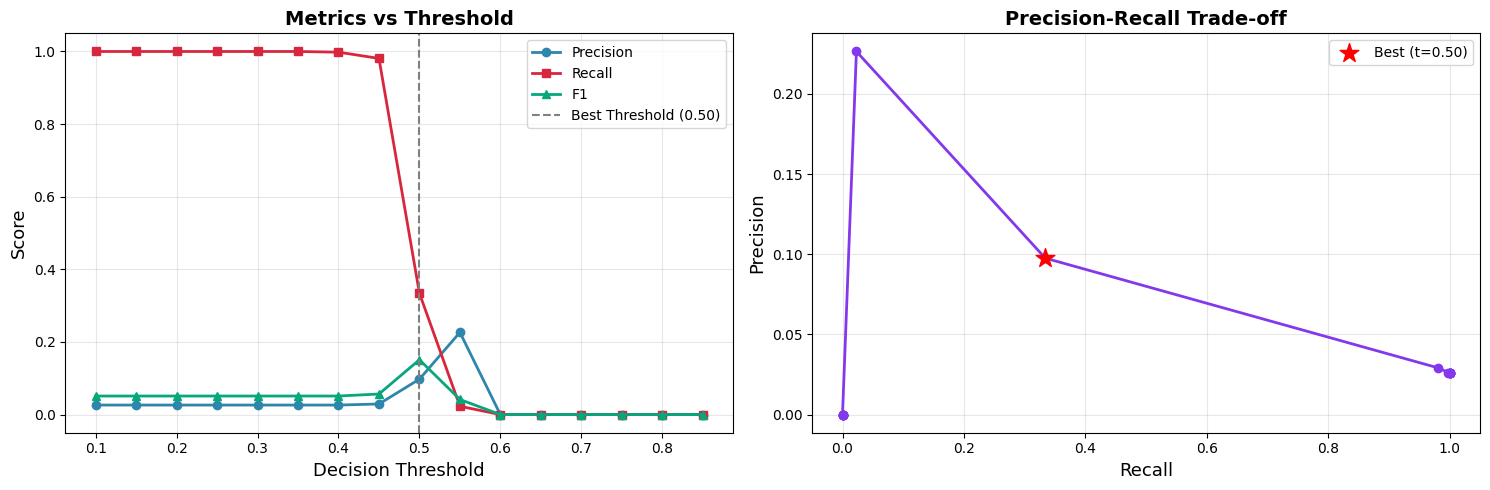


OPTIMIZED TEST RESULTS (threshold=0.50):
  Precision: 0.099
  Recall:    0.295
  F1 Score:  0.149
  AUC-ROC:   0.750

Comparison to default (0.5 threshold):
  F1:        0.147 → 0.149 (+1.1%)
  Precision: 0.097 → 0.099 (+2.1%)
  Recall:    0.300 → 0.295 (-1.8%)


In [15]:
# ===== THRESHOLD OPTIMIZATION =====
print("="*80)
print("THRESHOLD OPTIMIZATION FOR BEST F1")
print("="*80)

# Import necessary metrics
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Get predictions on validation set
model.eval()
with torch.no_grad():
    val_out = model(X_val, edge_index, nodes_val)
    val_probs = F.softmax(val_out, dim=1)[:, 1].cpu().numpy()

y_val_np = y_val.cpu().numpy()

# Try different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
best_f1 = 0
best_threshold = 0.5
results = []

for threshold in thresholds:
    val_preds = (val_probs > threshold).astype(int)

    precision = precision_score(y_val_np, val_preds, zero_division=0)
    recall = recall_score(y_val_np, val_preds, zero_division=0)
    f1 = f1_score(y_val_np, val_preds, zero_division=0)

    results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

results_df = pd.DataFrame(results)

print(f"\n🎯 Best threshold: {best_threshold:.2f}")
print(f"   Best F1: {best_f1:.3f}")

# Plot precision-recall vs threshold
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Metrics vs Threshold
axes[0].plot(results_df['threshold'], results_df['precision'],
            marker='o', label='Precision', linewidth=2, color='#2E86AB')
axes[0].plot(results_df['threshold'], results_df['recall'],
            marker='s', label='Recall', linewidth=2, color='#D7263D')
axes[0].plot(results_df['threshold'], results_df['f1'],
            marker='^', label='F1', linewidth=2, color='#06A77D')
axes[0].axvline(best_threshold, color='gray', linestyle='--',
               label=f'Best Threshold ({best_threshold:.2f})')
axes[0].set_xlabel('Decision Threshold', fontsize=13)
axes[0].set_ylabel('Score', fontsize=13)
axes[0].set_title('Metrics vs Threshold', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Precision-Recall Curve
axes[1].plot(results_df['recall'], results_df['precision'],
            marker='o', linewidth=2, color='#8338EC')
axes[1].scatter(results_df[results_df['threshold']==best_threshold]['recall'],
               results_df[results_df['threshold']==best_threshold]['precision'],
               s=200, color='red', marker='*', label=f'Best (t={best_threshold:.2f})', zorder=5)
axes[1].set_xlabel('Recall', fontsize=13)
axes[1].set_ylabel('Precision', fontsize=13)
axes[1].set_title('Precision-Recall Trade-off', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=300)
plt.show()

# Test with best threshold
with torch.no_grad():
    test_out = model(X_test, edge_index, nodes_test)
    test_probs = F.softmax(test_out, dim=1)[:, 1].cpu().numpy()
    test_preds_optimized = (test_probs > best_threshold).astype(int)

y_test_np = y_test.cpu().numpy()

# Evaluate
opt_precision = precision_score(y_test_np, test_preds_optimized, zero_division=0)
opt_recall = recall_score(y_test_np, test_preds_optimized, zero_division=0)
opt_f1 = f1_score(y_test_np, test_preds_optimized, zero_division=0)
opt_auc = roc_auc_score(y_test_np, test_probs)

print(f"\nOPTIMIZED TEST RESULTS (threshold={best_threshold:.2f}):")
print(f"  Precision: {opt_precision:.3f}")
print(f"  Recall:    {opt_recall:.3f}")
print(f"  F1 Score:  {opt_f1:.3f}")
print(f"  AUC-ROC:   {opt_auc:.3f}")

print(f"\nComparison to default (0.5 threshold):")
print(f"  F1:        {test_f1:.3f} → {opt_f1:.3f} ({(opt_f1-test_f1)/test_f1*100:+.1f}%)")
print(f"  Precision: {test_prec:.3f} → {opt_precision:.3f} ({(opt_precision-test_prec)/test_prec*100:+.1f}%)")
print(f"  Recall:    {test_rec:.3f} → {opt_recall:.3f} ({(opt_recall-test_rec)/test_rec*100:+.1f}%)")

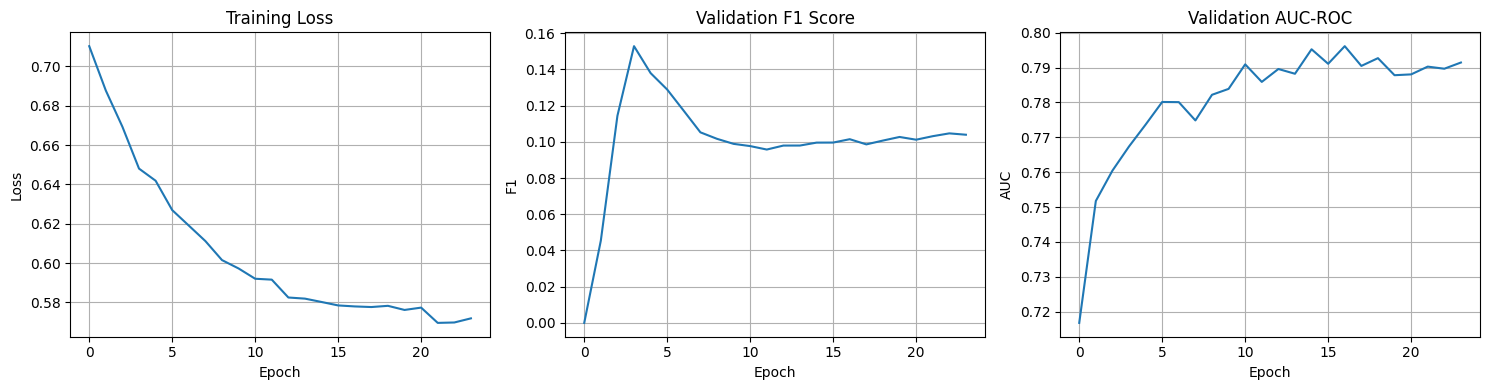

Best validation F1: 0.153
Best validation AUC: 0.796


In [16]:
# Visualize training progress
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'])
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot(history['val_f1'])
axes[1].set_title('Validation F1 Score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].grid(True)

axes[2].plot(history['val_auc'])
axes[2].set_title('Validation AUC-ROC')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].grid(True)

plt.tight_layout()
plt.show()

print(f"Best validation F1: {max(history['val_f1']):.3f}")
print(f"Best validation AUC: {max(history['val_auc']):.3f}")


In [17]:
# ===== CELL: INTERACTIVE RISK HEATMAP WITH FOLIUM =====
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

print("Creating interactive risk heatmap...")

# Get node coordinates and risk predictions
node_coords = np.array([[n[1]['y'], n[1]['x']] for n in G.nodes(data=True)])
all_nodes = list(G.nodes())

# Get risk predictions for all nodes (using test set as proxy)
# Create a mapping of predictions per node
node_risk_map = {}
for i, node_id in enumerate(nodes_test.cpu().numpy()):
    if node_id not in node_risk_map:
        node_risk_map[node_id] = []
    node_risk_map[node_id].append(test_prob[i])

# Average risk per node
node_risks = np.zeros(len(all_nodes))
for i, node_id in enumerate(all_nodes):
    if node_id in node_risk_map:
        node_risks[i] = np.mean(node_risk_map[node_id])

# Create base map centered on Manhattan
center_lat = node_coords[:, 0].mean()
center_lon = node_coords[:, 1].mean()

# Create heatmap layer
heatmap_data = [[node_coords[i][0], node_coords[i][1], node_risks[i]]
                for i in range(len(all_nodes))]

m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

HeatMap(heatmap_data).add_to(m)

# Display map
# m

print(" Heatmap created (displayed in output)")
m

Creating interactive risk heatmap...
 Heatmap created (displayed in output)


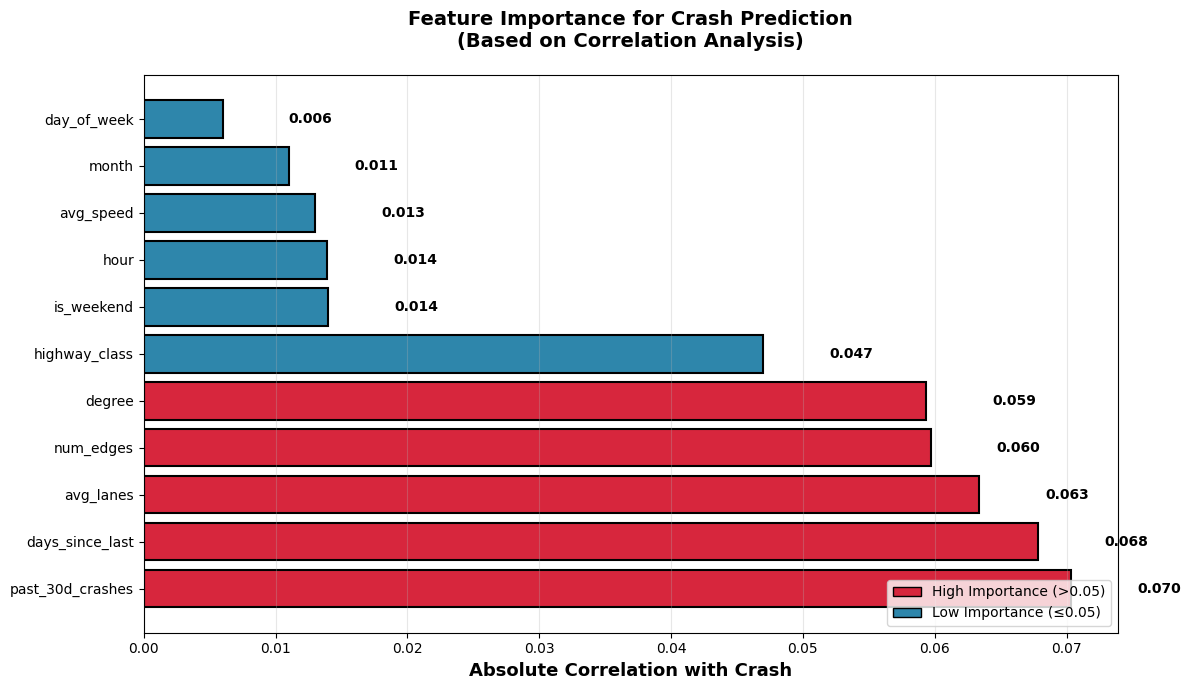

 Feature importance visualization saved

Top 3 most important features:
  1. past_30d_crashes: 0.070
  2. days_since_last: 0.068
  3. avg_lanes: 0.063


In [18]:
# ===== CELL: FEATURE IMPORTANCE VISUALIZATION =====

# Get feature names
feature_names = ['degree', 'num_edges', 'highway_class', 'avg_lanes', 'avg_speed',
                 'hour', 'day_of_week', 'is_weekend', 'month',
                 'past_30d_crashes', 'days_since_last']

# Compute correlation of features with crash labels
feature_importance = []
for i, feat in enumerate(feature_names):
    if feat in train_balanced.columns:
        corr = np.abs(train_balanced[feat].corr(train_balanced['has_crash']))
        feature_importance.append(corr)
    else:
        feature_importance.append(0)

# Sort by importance
sorted_indices = np.argsort(feature_importance)[::-1]
sorted_features = [feature_names[i] for i in sorted_indices]
sorted_importance = [feature_importance[i] for i in sorted_indices]

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#D7263D' if imp > 0.05 else '#2E86AB' for imp in sorted_importance]
bars = ax.barh(sorted_features, sorted_importance, color=colors, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Absolute Correlation with Crash', fontsize=13, fontweight='bold')
ax.set_title('Feature Importance for Crash Prediction\n(Based on Correlation Analysis)',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (feat, imp) in enumerate(zip(sorted_features, sorted_importance)):
    ax.text(imp + 0.005, i, f'{imp:.3f}', va='center', fontsize=10, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#D7263D', edgecolor='black', label='High Importance (>0.05)'),
    Patch(facecolor='#2E86AB', edgecolor='black', label='Low Importance (≤0.05)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Feature importance visualization saved")
print(f"\nTop 3 most important features:")
for i in range(min(3, len(sorted_features))):
    print(f"  {i+1}. {sorted_features[i]}: {sorted_importance[i]:.3f}")


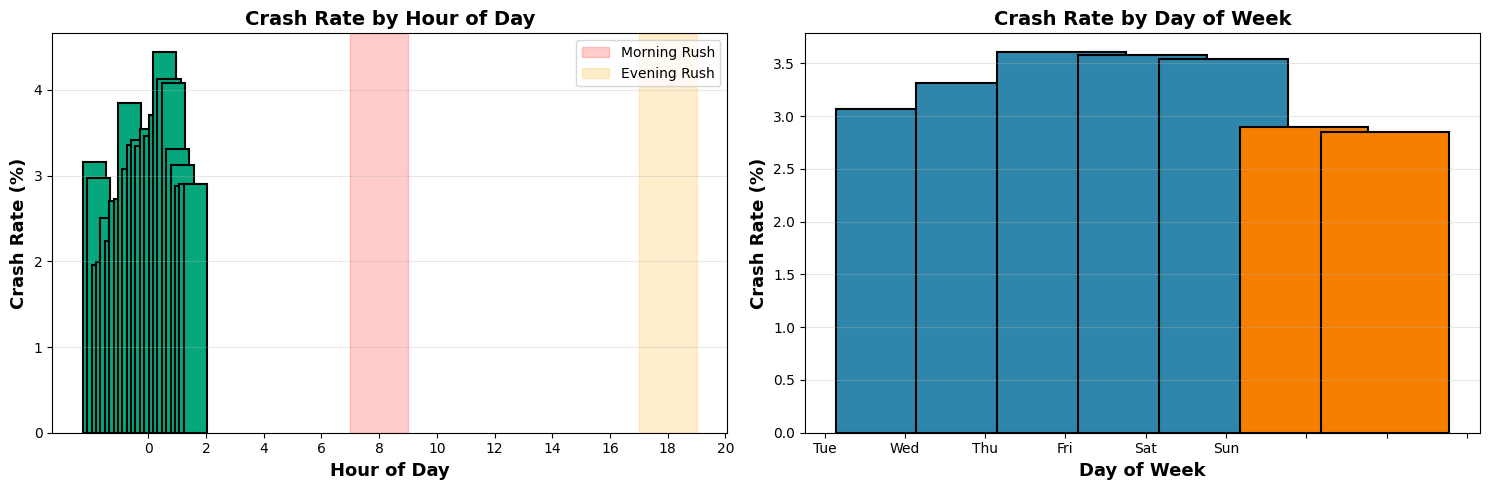

 Temporal patterns visualization saved


In [19]:
# ===== CELL: TEMPORAL PATTERNS VISUALIZATION =====

# Analyze crash patterns by hour and day of week
hourly_crashes = train_balanced.groupby('hour')['has_crash'].mean()
daily_crashes = train_balanced.groupby('day_of_week')['has_crash'].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Hour of day pattern
axes[0].bar(hourly_crashes.index, hourly_crashes.values * 100,
           color='#06A77D', edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Hour of Day', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Crash Rate (%)', fontsize=13, fontweight='bold')
axes[0].set_title('Crash Rate by Hour of Day', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticks(range(0, 24, 2))

# Add rush hour annotations
axes[0].axvspan(7, 9, alpha=0.2, color='red', label='Morning Rush')
axes[0].axvspan(17, 19, alpha=0.2, color='orange', label='Evening Rush')
axes[0].legend()

# Day of week pattern
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(daily_crashes.index, daily_crashes.values * 100,
           color=['#2E86AB']*5 + ['#F77F00']*2,  # Weekdays blue, weekends orange
           edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Day of Week', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Crash Rate (%)', fontsize=13, fontweight='bold')
axes[1].set_title('Crash Rate by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(day_names)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('temporal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Temporal patterns visualization saved")


In [20]:
# # Save predictions and important results
# print("Saving results...")

# # Save risk predictions
# risk_df.to_csv('nyc_risk_predictions.csv', index=False)
# print("Saved: nyc_risk_predictions.csv")

# # Save high-risk locations
# high_risk_nodes.to_csv('high_risk_locations.csv', index=False)
# print("Saved: high_risk_locations.csv")

# # Save model
# torch.save({
#     'model_state_dict': model.state_dict(),
#     'num_features': data.num_node_features,
#     'test_metrics': {
#         'accuracy': test_acc,
#         'f1_score': test_f1,
#         'auc_roc': test_auc
#     }
# }, 'accident_prediction_model.pth')
# print("Saved: accident_prediction_model.pth")

# print("\n All results saved successfully!")
